In [ ]:
!pip install xgboost shap imbalanced-learn

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving oncoguard_dataset_v2_main.csv to oncoguard_dataset_v2_main.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving colab_preprocessing.py to colab_preprocessing.py


In [ ]:
import os
os.listdir()

['.config',
 'oncoguard_dataset_v2_main.csv',
 'colab_preprocessing.py',
 'sample_data']

In [ ]:
with open("colab_preprocessing.py", "r", encoding="utf-8") as f:
    print(f.read())

"""
colab_preprocessing.py  —  ONCOGUARD-AI
KENDI KENDINE YETER: hicbir 'oncoguard_ai' import'u YOK.
Colab'da tek hucreye yapistir, calistir.

Mantik:
- Feature listesi CSV'den OTOMATIK turetilir (label_* ve meta kolonlar haric).
- scenario MODELE VERILMEZ (leakage).
- Medyanlar SADECE train'den ogrenilir (test'e uygulanir).
- CancerType / TreatmentType one-hot (kategoriler tum df'ten -> train/test ayni kolonlar).
- Overall label uzerinden stratified split.
"""

import json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ----------------------------------------------------------------------
# 0) CSV yolu (Colab'da kendi yoluna gore degistir)
# ----------------------------------------------------------------------
CSV_PATH = "oncoguard_dataset_v2_main.csv"

META_COLS = ["scenario", "CancerType", "TreatmentType"]   # feature DEGIL
CATEGORICAL = ["CancerType", "TreatmentType"]             # one-hot edilecek
STRATIFY_LABEL = "label_OverallClin

In [ ]:
%run colab_preprocessing.py

Dataset: 10008 satir x 87 kolon
  Feature (sayisal): 74
  Label: 10
  Meta (modele girmez): ['scenario', 'CancerType', 'TreatmentType']
  Toplam NaN: 1996
  object tipli kolonlar: ['scenario', 'CancerType', 'TreatmentType']

=== PREPROCESSING TAMAM ===
  X_train: (8006, 99)  X_test: (2002, 99)
  Model feature sayisi: 99
  Kalan NaN (train): 0 (0 olmali)
  'scenario' X icinde mi? False (False olmali)
  One-hot kolon sayisi: 13

  Overall dagilim (train vs test, oran):
    train: {0: np.float64(0.172), 1: np.float64(0.338), 2: np.float64(0.204), 3: np.float64(0.286)}
    test: {0: np.float64(0.172), 1: np.float64(0.339), 2: np.float64(0.204), 3: np.float64(0.286)}


In [ ]:
import os
os.listdir()

['.config',
 'preprocessor.json',
 'X_test.csv',
 'X_train.csv',
 'y_train.csv',
 'y_test.csv',
 'oncoguard_dataset_v2_main.csv',
 'colab_preprocessing.py',
 'sample_data']

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

target = "label_InfectionRisk"

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train[target])

y_pred = model.predict(X_test)

print("Target:", target)
print("Accuracy:", accuracy_score(y_test[target], y_pred))
print("\nClassification Report:")
print(classification_report(y_test[target], y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test[target], y_pred))

Target: label_InfectionRisk
Accuracy: 0.7907092907092907

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1253
           1       0.63      0.51      0.56       432
           2       0.58      0.72      0.64       222
           3       0.74      0.31      0.43        95

    accuracy                           0.79      2002
   macro avg       0.71      0.62      0.64      2002
weighted avg       0.78      0.79      0.78      2002


Confusion Matrix:
[[1176   76    1    0]
 [ 164  219   49    0]
 [   0   53  159   10]
 [   0    0   66   29]]


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

target = "label_InfectionRisk"

xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=4,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train[target])

y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test[target], y_pred))
print("\nClassification Report:")
print(classification_report(y_test[target], y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test[target], y_pred))

Accuracy: 0.8016983016983017

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.93      0.91      1253
           1       0.64      0.56      0.60       432
           2       0.61      0.68      0.65       222
           3       0.75      0.43      0.55        95

    accuracy                           0.80      2002
   macro avg       0.72      0.65      0.67      2002
weighted avg       0.80      0.80      0.80      2002


Confusion Matrix:
[[1171   80    2    0]
 [ 150  241   41    0]
 [   0   56  152   14]
 [   0    0   54   41]]


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
50,FeverAndLowANCFlag,0.197731
47,FeverCount3,0.104293
29,ANCGrade,0.072529
48,FeverCount7,0.054215
6,PreviousTreatmentDelay,0.053619
17,BaselineANC,0.040394
66,FatigueTrendDir,0.024860
97,TreatmentType_Radiation,0.019512
51,FatigueMean3,0.019027
10,HasDiabetes,0.017863


In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

sw = compute_sample_weight(class_weight="balanced", y=y_train[target])
xgb_model.fit(X_train, y_train[target], sample_weight=sw)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_class=4, ...)

In [ ]:
y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test[target], y_pred))
print(classification_report(y_test[target], y_pred))

Accuracy: 0.7967032967032966
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      1253
           1       0.61      0.60      0.60       432
           2       0.60      0.69      0.64       222
           3       0.71      0.55      0.62        95

    accuracy                           0.80      2002
   macro avg       0.71      0.69      0.69      2002
weighted avg       0.80      0.80      0.80      2002



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

target = "label_InfectionRisk"

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        multi_class="multinomial",
        random_state=42
    ))
])

log_model.fit(X_train, y_train[target])

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test[target], y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test[target], y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test[target], y_pred_log))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Results
Accuracy: 0.7572427572427572

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      1253
           1       0.53      0.62      0.57       432
           2       0.56      0.55      0.55       222
           3       0.55      0.80      0.66        95

    accuracy                           0.76      2002
   macro avg       0.64      0.70      0.66      2002
weighted avg       0.78      0.76      0.77      2002


Confusion Matrix:
[[1051  195    7    0]
 [  88  268   70    6]
 [   0   46  121   55]
 [   0    0   19   76]]


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

target = "label_CachexiaRisk"

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

log_model.fit(X_train, y_train[target])

y_pred_log = log_model.predict(X_test)

print("="*60)
print("LOGISTIC REGRESSION")
print("="*60)
print("Accuracy:", accuracy_score(y_test[target], y_pred_log))
print(classification_report(y_test[target], y_pred_log))
print(confusion_matrix(y_test[target], y_pred_log))

LOGISTIC REGRESSION
Accuracy: 0.8606393606393606
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1802
           1       0.16      0.48      0.24        83
           2       0.68      0.73      0.70        95
           3       0.42      0.50      0.46        22

    accuracy                           0.86      2002
   macro avg       0.56      0.65      0.58      2002
weighted avg       0.93      0.86      0.89      2002

[[1603  198    1    0]
 [  21   40   21    1]
 [   1   11   69   14]
 [   0    1   10   11]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier

target = "label_CachexiaRisk"

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train[target])

y_pred_rf = rf_model.predict(X_test)

print("="*60)
print("RANDOM FOREST")
print("="*60)
print("Accuracy:", accuracy_score(y_test[target], y_pred_rf))
print(classification_report(y_test[target], y_pred_rf))
print(confusion_matrix(y_test[target], y_pred_rf))

RANDOM FOREST
Accuracy: 0.954045954045954
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1802
           1       0.61      0.34      0.43        83
           2       0.70      0.84      0.77        95
           3       0.60      0.41      0.49        22

    accuracy                           0.95      2002
   macro avg       0.72      0.65      0.67      2002
weighted avg       0.95      0.95      0.95      2002

[[1793    9    0    0]
 [  33   28   22    0]
 [   0    9   80    6]
 [   1    0   12    9]]


In [ ]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

target = "label_CachexiaRisk"

sw = compute_sample_weight(
    class_weight="balanced",
    y=y_train[target]
)

xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=4,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train[target],
    sample_weight=sw
)

y_pred_xgb = xgb_model.predict(X_test)

print("="*60)
print("WEIGHTED XGBOOST")
print("="*60)
print("Accuracy:", accuracy_score(y_test[target], y_pred_xgb))
print(classification_report(y_test[target], y_pred_xgb))
print(confusion_matrix(y_test[target], y_pred_xgb))

WEIGHTED XGBOOST
Accuracy: 0.9585414585414586
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1802
           1       0.67      0.46      0.54        83
           2       0.70      0.85      0.77        95
           3       0.60      0.41      0.49        22

    accuracy                           0.96      2002
   macro avg       0.74      0.68      0.70      2002
weighted avg       0.96      0.96      0.96      2002

[[1791   11    0    0]
 [  23   38   22    0]
 [   1    7   81    6]
 [   0    1   12    9]]


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset5.zip to dataset5.zip


In [ ]:
import zipfile

with zipfile.ZipFile("dataset5.zip", "r") as z:
    print(z.namelist())

['oncoguard_dataset_v21_main.csv', 'synthetic_data_v2.py']


In [ ]:
import zipfile

with zipfile.ZipFile("dataset5.zip", "r") as z:
    z.extractall("dataset5")

print("dataset5 extracted")

dataset5 extracted


In [ ]:
import pandas as pd

df_v5 = pd.read_csv("dataset5/oncoguard_dataset_v21_main.csv")

print("Shape:", df_v5.shape)
df_v5.head()

Shape: (14998, 87)


,Age,ECOG,CycleDay,CycleNumber,BMI,PreviousNeutropenia,PreviousTreatmentDelay,PreviousSevereToxicity,DoseReductionFlag,GCSFUseFlag,...,label_CachexiaRisk,label_DehydrationRisk,label_RenalToxicityRisk,label_HepaticToxicityRisk,label_ImmunotherapyAdverseEventRisk,label_TreatmentDelayRisk,label_OverallClinicalDeteriorationRisk,scenario,CancerType,TreatmentType
0,39,0,8,5,19.0,0,0,0,0,1,...,0,0,0,0,0,0,0,StablePatient,Gastric,Immunotherapy
1,47,2,7,1,25.3,0,0,0,0,1,...,0,0,0,0,0,1,0,StablePatient,Leukemia,Chemotherapy
2,71,2,12,5,22.0,0,0,0,0,0,...,0,0,0,0,0,0,1,StablePatient,Pancreatic,Immunotherapy
3,68,2,10,1,25.4,0,0,1,1,0,...,0,0,0,0,0,2,1,StablePatient,Lymphoma,Chemotherapy
4,56,2,13,1,31.2,0,0,0,0,0,...,0,0,0,0,0,0,0,StablePatient,Pancreatic,Radiation


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

META_COLS = ["scenario", "CancerType", "TreatmentType"]

label_cols = [c for c in df_v5.columns if c.startswith("label_")]

feature_cols = [
    c for c in df_v5.columns
    if not c.startswith("label_") and c not in META_COLS
]

# One-hot encoding
df_encoded = pd.get_dummies(
    df_v5,
    columns=["CancerType", "TreatmentType"],
    drop_first=False
)

# Feature kolonları yeniden oluştur
feature_cols_encoded = [
    c for c in df_encoded.columns
    if not c.startswith("label_")
    and c != "scenario"
]

X = df_encoded[feature_cols_encoded]
y = df_encoded[label_cols]

# Eksik değerleri medyanla doldur
X = X.fillna(X.median(numeric_only=True))

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y["label_OverallClinicalDeteriorationRisk"]
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("Toplam NaN:", X_train.isna().sum().sum())

X_train: (11998, 87)
X_test : (3000, 87)
y_train: (11998, 10)
y_test : (3000, 10)
Toplam NaN: 0


In [ ]:
for col in label_cols:
    print("\n", col)
    print(df_v5[col].value_counts().sort_index())


 label_InfectionRisk
label_InfectionRisk
0    9765
1    2777
2    1690
3     766
Name: count, dtype: int64

 label_FebrileNeutropeniaRisk
label_FebrileNeutropeniaRisk
0    12754
1      862
2      664
3      718
Name: count, dtype: int64

 label_MalnutritionRisk
label_MalnutritionRisk
0    10462
1     1607
2     1812
3     1117
Name: count, dtype: int64

 label_CachexiaRisk
label_CachexiaRisk
0    12879
1      471
2     1103
3      545
Name: count, dtype: int64

 label_DehydrationRisk
label_DehydrationRisk
0    11767
1     1569
2      940
3      722
Name: count, dtype: int64

 label_RenalToxicityRisk
label_RenalToxicityRisk
0    11619
1     1623
2      999
3      757
Name: count, dtype: int64

 label_HepaticToxicityRisk
label_HepaticToxicityRisk
0    12523
1     1075
2      570
3      830
Name: count, dtype: int64

 label_ImmunotherapyAdverseEventRisk
label_ImmunotherapyAdverseEventRisk
0    13496
1      323
2      365
3      814
Name: count, dtype: int64

 label_TreatmentDelayRisk
lab

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

target = "label_CachexiaRisk"

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

log_model.fit(X_train, y_train[target])

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test[target], y_pred))
print(classification_report(y_test[target], y_pred))

Accuracy: 0.8713333333333333
              precision    recall  f1-score   support

           0       0.99      0.92      0.95      2583
           1       0.16      0.52      0.25        94
           2       0.71      0.51      0.60       216
           3       0.57      0.77      0.65       107

    accuracy                           0.87      3000
   macro avg       0.61      0.68      0.61      3000
weighted avg       0.93      0.87      0.89      3000



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

target = "label_CachexiaRisk"

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train[target])

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test[target], y_pred_rf))
print(classification_report(y_test[target], y_pred_rf))

Accuracy: 0.948
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2583
           1       0.74      0.30      0.42        94
           2       0.69      0.81      0.75       216
           3       0.64      0.57      0.60       107

    accuracy                           0.95      3000
   macro avg       0.76      0.67      0.69      3000
weighted avg       0.95      0.95      0.94      3000



In [ ]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, accuracy_score

target = "label_CachexiaRisk"

sw = compute_sample_weight(
    class_weight="balanced",
    y=y_train[target]
)

xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=4,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train[target],
    sample_weight=sw
)

y_pred_xgb = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test[target], y_pred_xgb))
print(classification_report(y_test[target], y_pred_xgb))

Accuracy: 0.9463333333333334
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2583
           1       0.70      0.41      0.52        94
           2       0.70      0.73      0.71       216
           3       0.58      0.61      0.59       107

    accuracy                           0.95      3000
   macro avg       0.74      0.69      0.71      3000
weighted avg       0.94      0.95      0.94      3000



In [ ]:
label_cols

['label_InfectionRisk',
 'label_FebrileNeutropeniaRisk',
 'label_MalnutritionRisk',
 'label_CachexiaRisk',
 'label_DehydrationRisk',
 'label_RenalToxicityRisk',
 'label_HepaticToxicityRisk',
 'label_ImmunotherapyAdverseEventRisk',
 'label_TreatmentDelayRisk',
 'label_OverallClinicalDeteriorationRisk']

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

results = []

for target in label_cols:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ])

    model.fit(X_train, y_train[target])

    y_pred = model.predict(X_test)

    report = classification_report(
        y_test[target],
        y_pred,
        output_dict=True,
        zero_division=0
    )

    results.append({
        "Risk": target,
        "Red Recall": round(report["3"]["recall"], 3),
        "Red F1": round(report["3"]["f1-score"], 3),
        "Accuracy": round(report["accuracy"], 3)
    })

import pandas as pd

lr_results = pd.DataFrame(results)

lr_results

,Risk,Red Recall,Red F1,Accuracy
0,label_InfectionRisk,0.807,0.697,0.764
1,label_FebrileNeutropeniaRisk,0.896,0.871,0.922
2,label_MalnutritionRisk,0.819,0.747,0.839
3,label_CachexiaRisk,0.766,0.653,0.871
4,label_DehydrationRisk,0.811,0.768,0.844
5,label_RenalToxicityRisk,0.786,0.720,0.852
6,label_HepaticToxicityRisk,0.719,0.694,0.910
7,label_ImmunotherapyAdverseEventRisk,0.788,0.809,0.934
8,label_TreatmentDelayRisk,0.778,0.760,0.776
9,label_OverallClinicalDeteriorationRisk,0.667,0.703,0.598


In [ ]:
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
import pandas as pd

results = []

for target in label_cols:

    sw = compute_sample_weight(
        class_weight="balanced",
        y=y_train[target]
    )

    model = XGBClassifier(
        objective="multi:softmax",
        num_class=4,
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(
        X_train,
        y_train[target],
        sample_weight=sw
    )

    y_pred = model.predict(X_test)

    report = classification_report(
        y_test[target],
        y_pred,
        output_dict=True,
        zero_division=0
    )

    results.append({
        "Risk": target,
        "Red Recall": round(report["3"]["recall"], 3),
        "Red F1": round(report["3"]["f1-score"], 3),
        "Accuracy": round(report["accuracy"], 3)
    })

xgb_results = pd.DataFrame(results)

xgb_results

,Risk,Red Recall,Red F1,Accuracy
0,label_InfectionRisk,0.653,0.658,0.803
1,label_FebrileNeutropeniaRisk,0.889,0.848,0.935
2,label_MalnutritionRisk,0.769,0.755,0.874
3,label_CachexiaRisk,0.607,0.594,0.946
4,label_DehydrationRisk,0.818,0.791,0.885
5,label_RenalToxicityRisk,0.736,0.718,0.890
6,label_HepaticToxicityRisk,0.848,0.729,0.924
7,label_ImmunotherapyAdverseEventRisk,0.872,0.827,0.963
8,label_TreatmentDelayRisk,0.848,0.780,0.795
9,label_OverallClinicalDeteriorationRisk,0.752,0.764,0.657


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

def metrics_row(name, target, y_true, y_pred):
    r = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    return {
        "Risk": target.replace("label_", ""),
        "Model": name,
        "Accuracy": round(r["accuracy"], 3),
        "MacroF1": round(r["macro avg"]["f1-score"], 3),
        "RedRecall": round(r["3"]["recall"], 3) if "3" in r else 0.0,
        "RedPrecision": round(r["3"]["precision"], 3) if "3" in r else 0.0,
        "RedF1": round(r["3"]["f1-score"], 3) if "3" in r else 0.0,
    }

rows = []
for target in label_cols:
    # --- LR ---
    lr = Pipeline([("scaler", StandardScaler()),
                   ("clf", LogisticRegression(max_iter=2000,
                                              class_weight="balanced",
                                              random_state=42))])
    lr.fit(X_train, y_train[target])
    rows.append(metrics_row("LR", target, y_test[target], lr.predict(X_test)))

    # --- XGBoost ---
    sw = compute_sample_weight(class_weight="balanced", y=y_train[target])
    xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        random_state=42, eval_metric="mlogloss")
    xgb.fit(X_train, y_train[target], sample_weight=sw)
    rows.append(metrics_row("XGB", target, y_test[target], xgb.predict(X_test)))

comparison = pd.DataFrame(rows)
comparison.to_csv("model_comparison.csv", index=False)   # tez/grafik için kaydet
comparison

,Risk,Model,Accuracy,MacroF1,RedRecall,RedPrecision,RedF1
0,InfectionRisk,LR,0.764,0.679,0.807,0.614,0.697
1,InfectionRisk,XGB,0.803,0.697,0.653,0.662,0.658
2,FebrileNeutropeniaRisk,LR,0.922,0.755,0.896,0.846,0.871
3,FebrileNeutropeniaRisk,XGB,0.935,0.745,0.889,0.811,0.848
4,MalnutritionRisk,LR,0.839,0.719,0.819,0.686,0.747
5,MalnutritionRisk,XGB,0.874,0.747,0.769,0.741,0.755
6,CachexiaRisk,LR,0.871,0.612,0.766,0.569,0.653
7,CachexiaRisk,XGB,0.946,0.705,0.607,0.580,0.594
8,DehydrationRisk,LR,0.844,0.708,0.811,0.730,0.768
9,DehydrationRisk,XGB,0.885,0.752,0.818,0.765,0.791


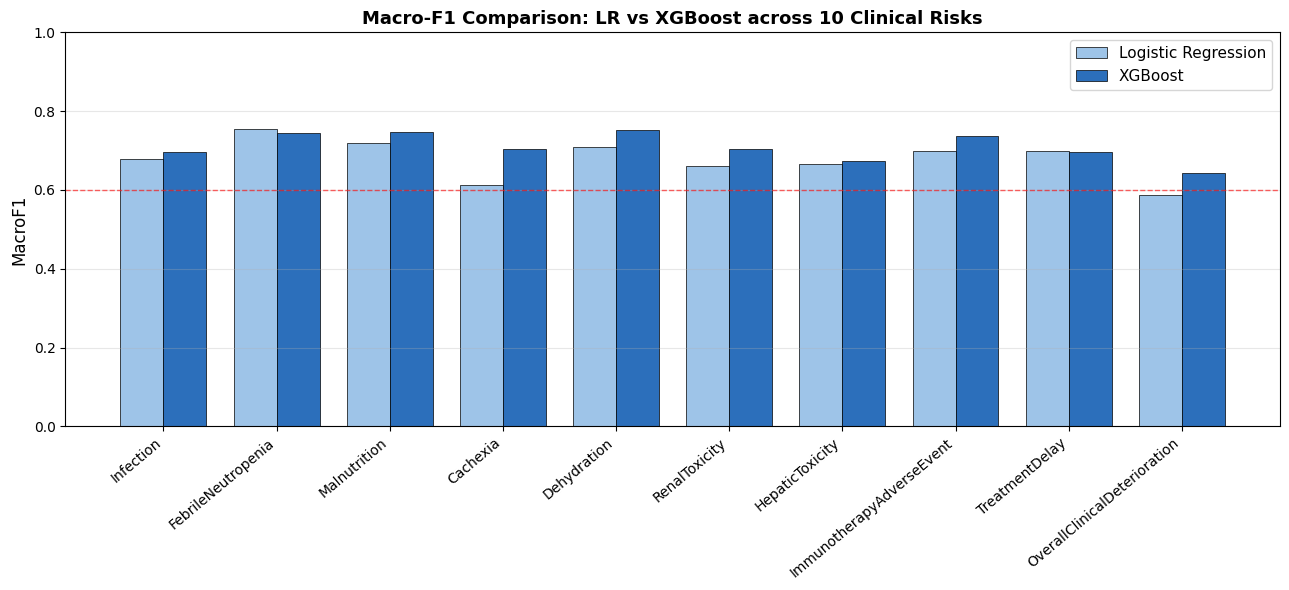

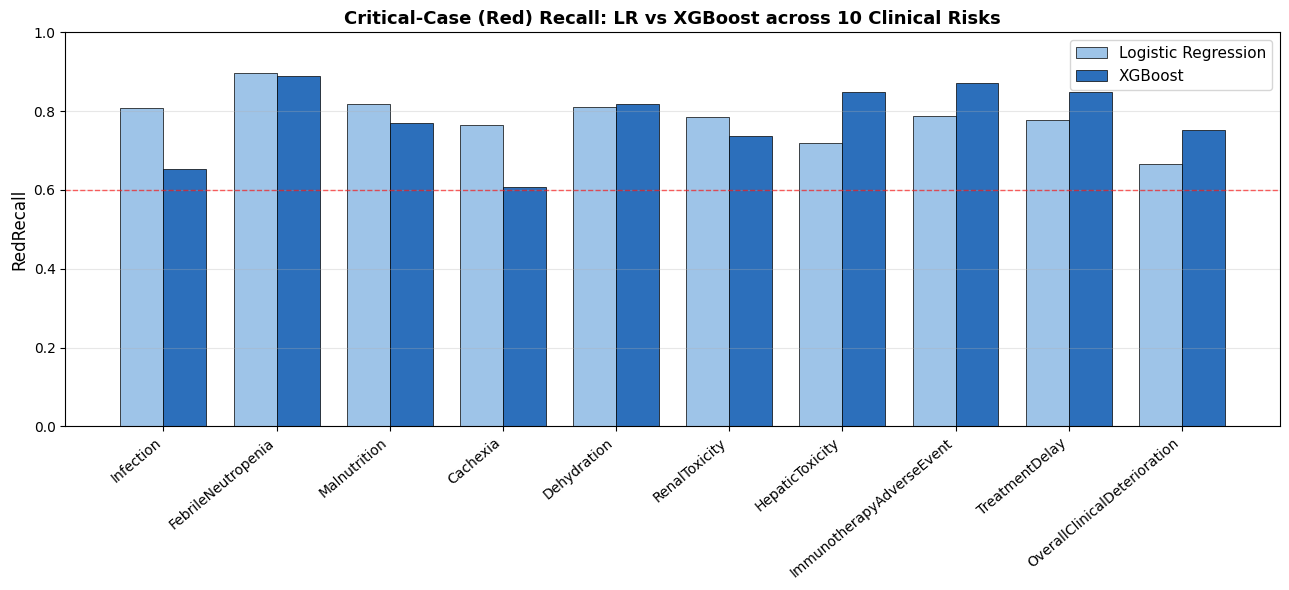

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("model_comparison.csv")
risks = df["Risk"].unique()
x = np.arange(len(risks))
w = 0.38

def grouped_bar(metric, title, fname):
    lr = df[df.Model == "LR"].set_index("Risk").loc[risks, metric].values
    xgb = df[df.Model == "XGB"].set_index("Risk").loc[risks, metric].values
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.bar(x - w/2, lr, w, label="Logistic Regression", color="#9ec4e8", edgecolor="black", linewidth=0.5)
    ax.bar(x + w/2, xgb, w, label="XGBoost", color="#2c6fbb", edgecolor="black", linewidth=0.5)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels([r.replace("Risk", "") for r in risks], rotation=40, ha="right", fontsize=10)
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(0.6, color="red", linestyle="--", linewidth=1, alpha=0.6)  # esik referansi
    plt.tight_layout()
    plt.savefig(fname + ".png", dpi=300, bbox_inches="tight")
    plt.savefig(fname + ".pdf", bbox_inches="tight")
    plt.show()

# Figure 1: Macro-F1 (genel performans, ana metrik)
grouped_bar("MacroF1", "Macro-F1 Comparison: LR vs XGBoost across 10 Clinical Risks", "fig1_macrof1")

# Figure 2: Red Recall (kritik vaka yakalama)
grouped_bar("RedRecall", "Critical-Case (Red) Recall: LR vs XGBoost across 10 Clinical Risks", "fig2_red_recall")

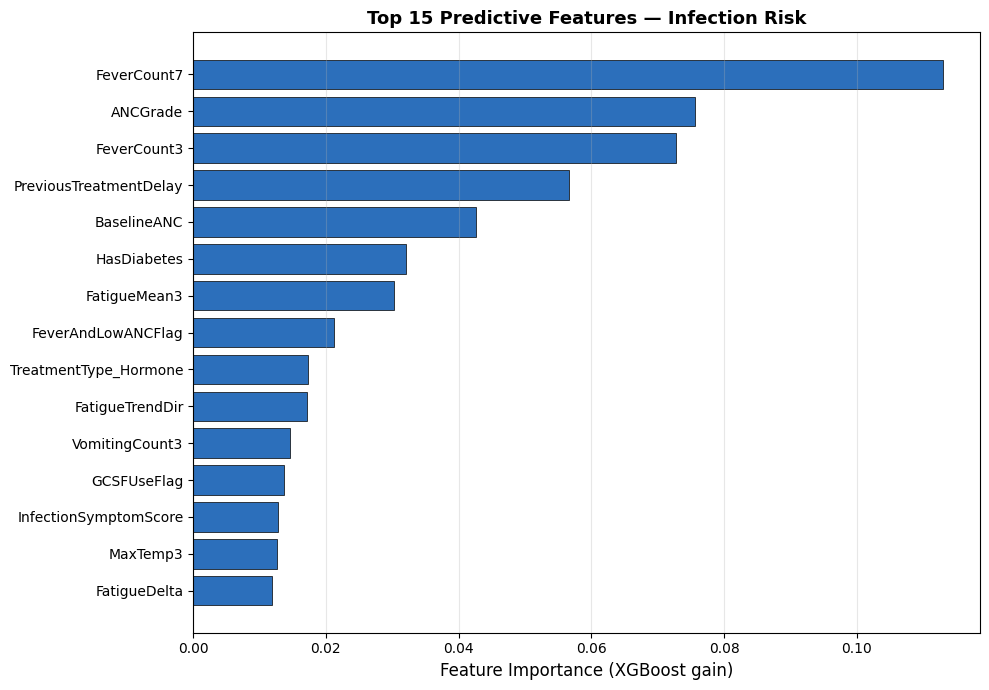

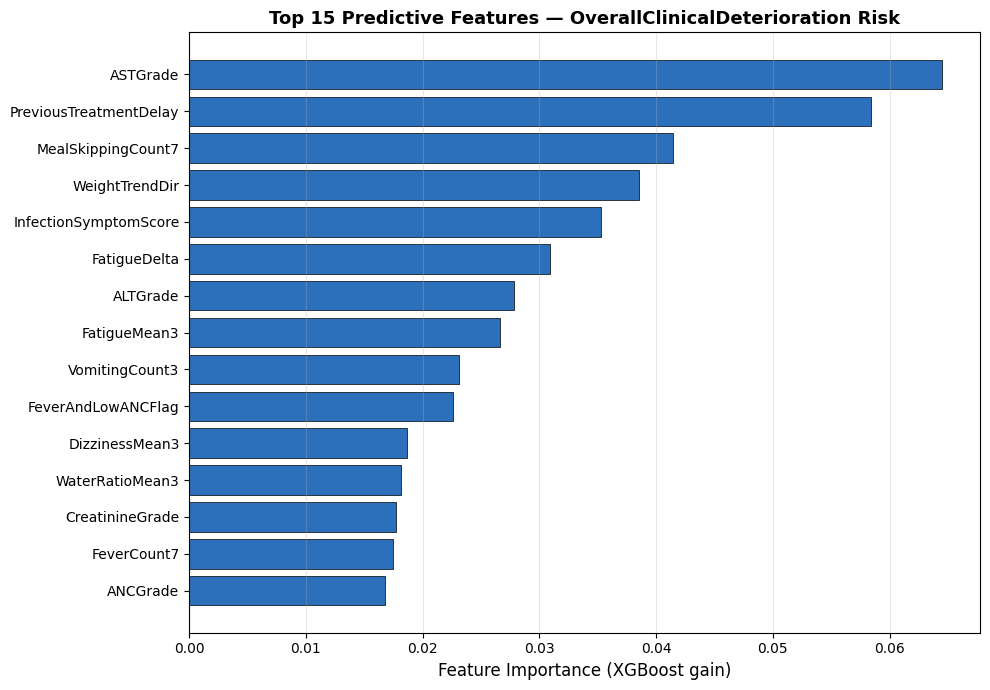

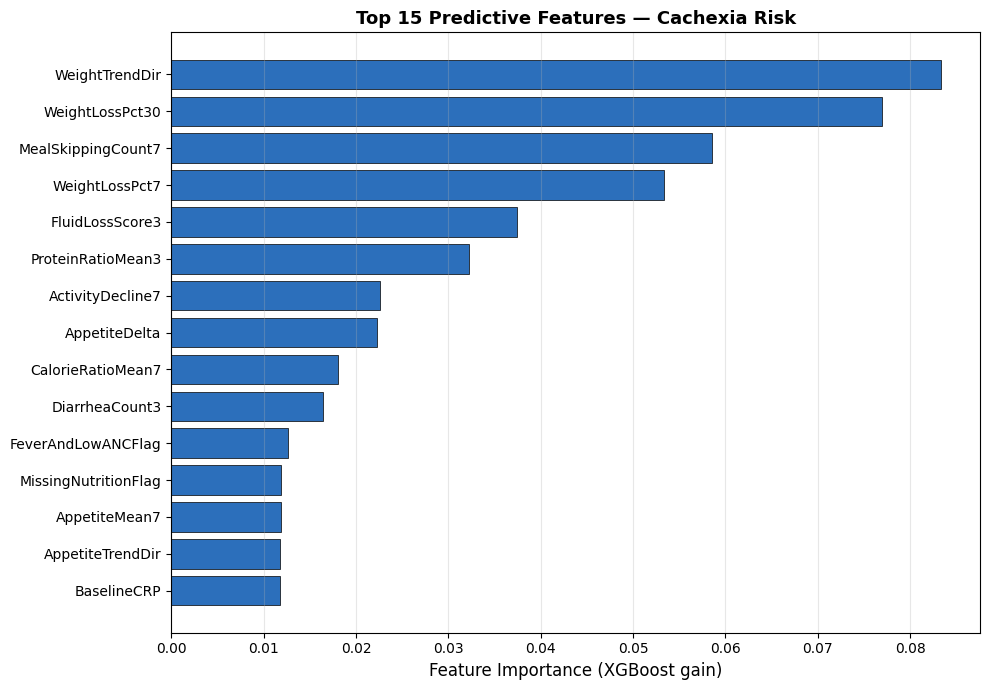

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

risks_to_plot = ["label_InfectionRisk",
                 "label_OverallClinicalDeteriorationRisk",
                 "label_CachexiaRisk"]

for target in risks_to_plot:
    sw = compute_sample_weight(class_weight="balanced", y=y_train[target])
    model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, eval_metric="mlogloss")
    model.fit(X_train, y_train[target], sample_weight=sw)

    imp = (pd.DataFrame({"Feature": X_train.columns,
                         "Importance": model.feature_importances_})
           .sort_values("Importance", ascending=False)
           .head(15)
           .iloc[::-1])  # en onemli ustte gozuksun

    name = target.replace("label_", "").replace("Risk", "")
    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(imp["Feature"], imp["Importance"], color="#2c6fbb", edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Feature Importance (XGBoost gain)", fontsize=12)
    ax.set_title(f"Top 15 Predictive Features — {name} Risk", fontsize=13, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    fname = f"fig_importance_{name}"
    plt.savefig(fname + ".png", dpi=300, bbox_inches="tight")
    plt.savefig(fname + ".pdf", bbox_inches="tight")
    plt.show()

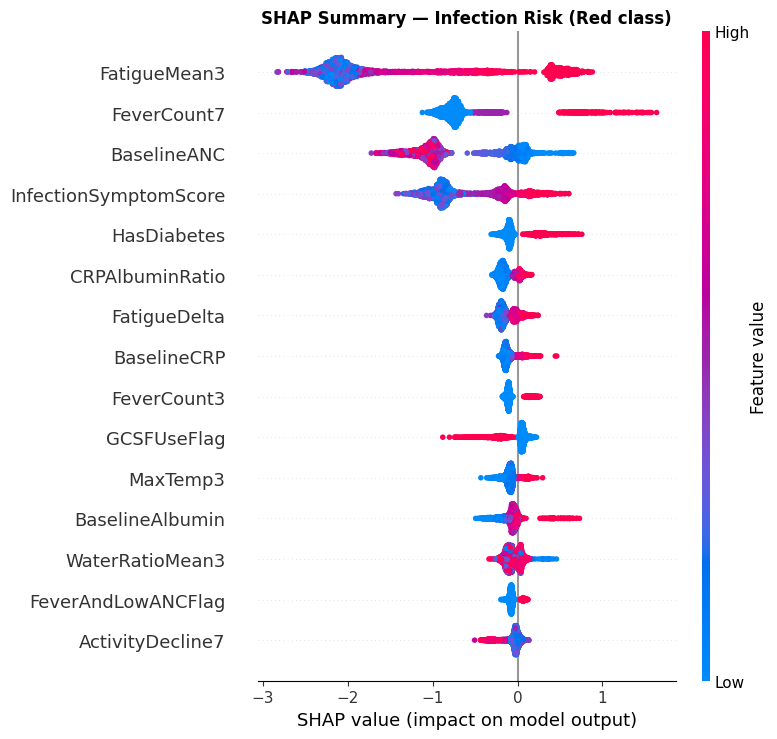

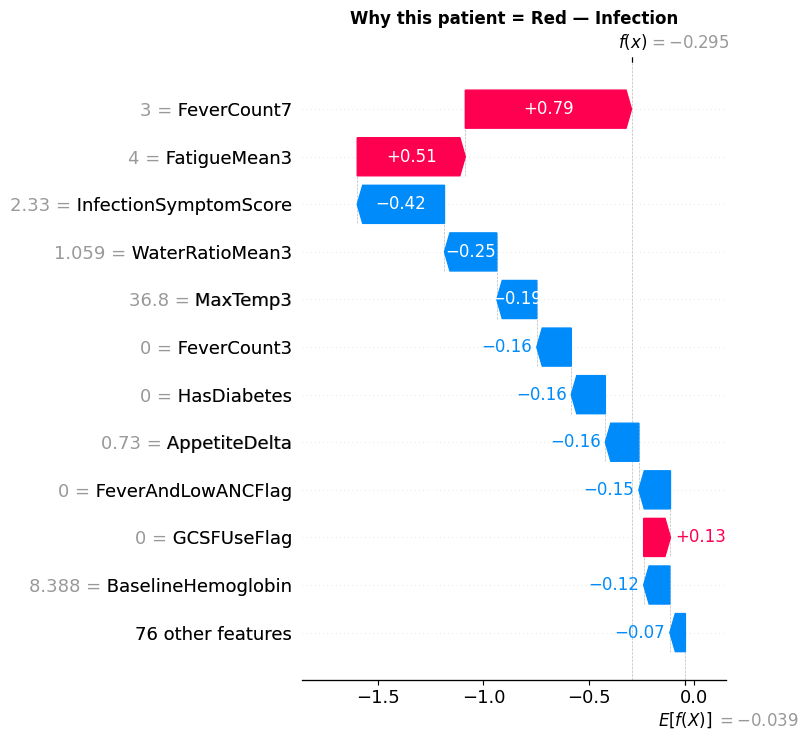

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

target = "label_InfectionRisk"
RED_CLASS = 3   # acikladigimiz sinif: Red (kritik)

# modeli egit
sw = compute_sample_weight(class_weight="balanced", y=y_train[target])
model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      random_state=42, eval_metric="mlogloss")
model.fit(X_train, y_train[target], sample_weight=sw)

# SHAP degerleri (agac modeli icin hizli explainer)
explainer = shap.TreeExplainer(model)
sv = explainer.shap_values(X_test)

# cok-sinifli ciktiyi Red sinifina indirge (surum farkina dayanikli)
def red_slice(sv, red=RED_CLASS):
    if isinstance(sv, list):              # eski API: sinif listesi
        return sv[red]
    if hasattr(sv, "ndim") and sv.ndim == 3:   # yeni API: (n, feat, sinif)
        return sv[:, :, red]
    return sv
sv_red = red_slice(sv)

name = target.replace("label_", "").replace("Risk", "")

# --- Grafik 1: SHAP summary (beeswarm) — Red sinifi ---
plt.figure()
shap.summary_plot(sv_red, X_test, max_display=15, show=False)
plt.title(f"SHAP Summary — {name} Risk (Red class)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"fig_shap_summary_{name}.png", dpi=300, bbox_inches="tight")
plt.savefig(f"fig_shap_summary_{name}.pdf", bbox_inches="tight")
plt.show()

# --- Grafik 2: tek bir kritik hastayi acikla (waterfall) ---
# gercekten Red olan bir test ornegi sec
red_idx = np.where(y_test[target].values == RED_CLASS)[0]
i = int(red_idx[0]) if len(red_idx) else 0
base = explainer.expected_value
base = base[RED_CLASS] if isinstance(base, (list, np.ndarray)) and np.ndim(base) > 0 else base

expl = shap.Explanation(values=sv_red[i],
                        base_values=base,
                        data=X_test.iloc[i].values,
                        feature_names=list(X_test.columns))
plt.figure()
shap.plots.waterfall(expl, max_display=12, show=False)
plt.title(f"Why this patient = Red — {name}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"fig_shap_waterfall_{name}.png", dpi=300, bbox_inches="tight")
plt.savefig(f"fig_shap_waterfall_{name}.pdf", bbox_inches="tight")
plt.show()

=== SHAP: label_CachexiaRisk ===


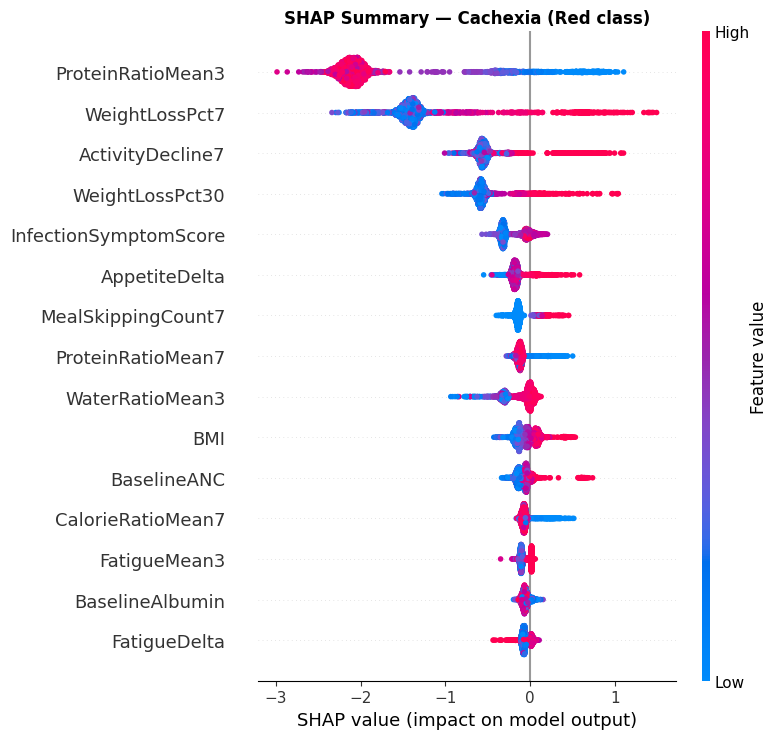

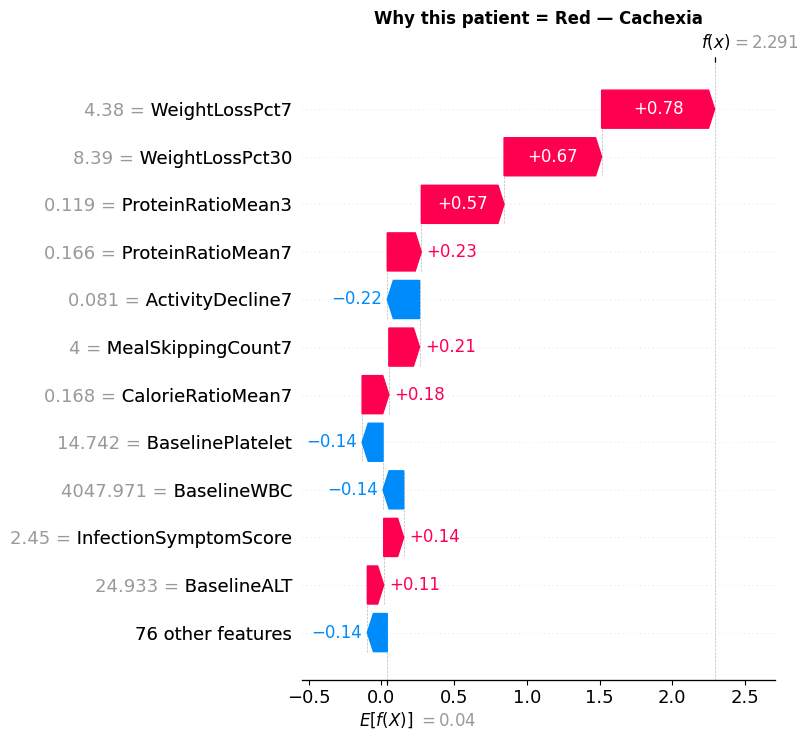

=== SHAP: label_OverallClinicalDeteriorationRisk ===


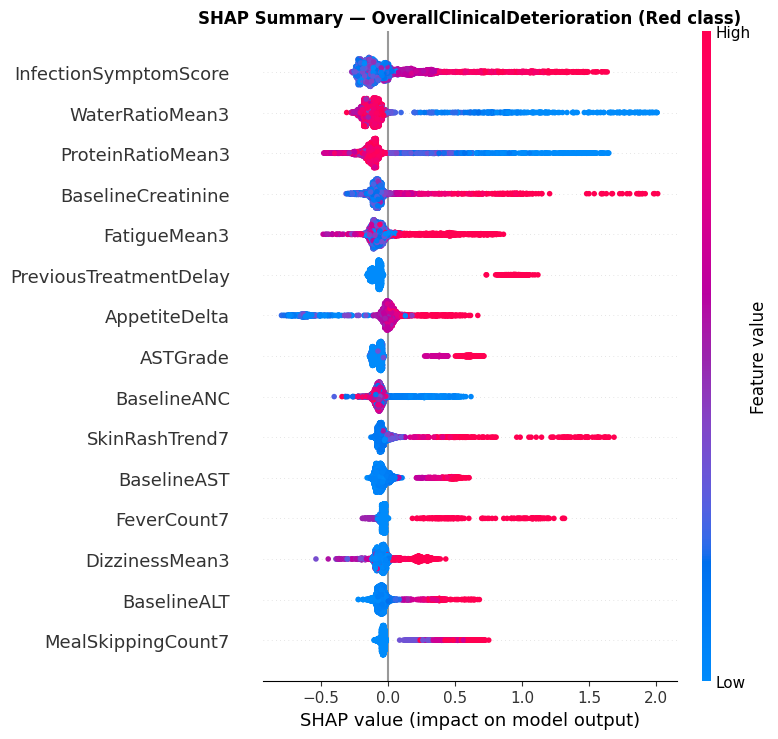

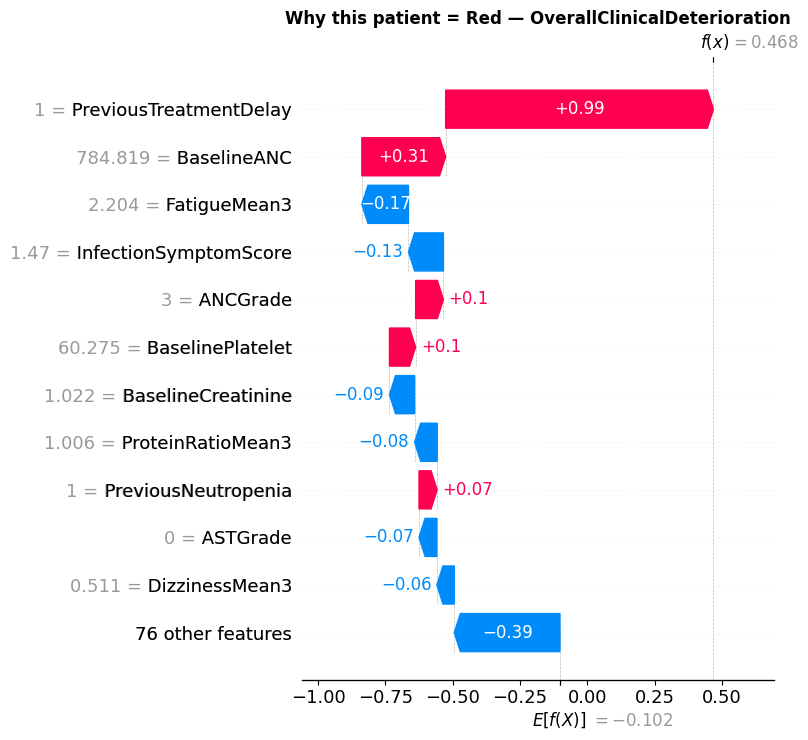

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

RED_CLASS = 3

def red_slice(sv, red=RED_CLASS):
    if isinstance(sv, list):                      # eski API
        return sv[red]
    if hasattr(sv, "ndim") and sv.ndim == 3:      # yeni API (n, feat, sinif)
        return sv[:, :, red]
    return sv

def shap_for(target):
    sw = compute_sample_weight(class_weight="balanced", y=y_train[target])
    model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8,
                          random_state=42, eval_metric="mlogloss")
    model.fit(X_train, y_train[target], sample_weight=sw)

    explainer = shap.TreeExplainer(model)
    sv_red = red_slice(explainer.shap_values(X_test))
    name = target.replace("label_", "").replace("Risk", "")

    # --- Summary (beeswarm) ---
    plt.figure()
    shap.summary_plot(sv_red, X_test, max_display=15, show=False)
    plt.title(f"SHAP Summary — {name} (Red class)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"fig_shap_summary_{name}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"fig_shap_summary_{name}.pdf", bbox_inches="tight")
    plt.show()

    # --- Waterfall (tek kritik hasta) ---
    red_idx = np.where(y_test[target].values == RED_CLASS)[0]
    i = int(red_idx[0]) if len(red_idx) else 0
    base = explainer.expected_value
    base = base[RED_CLASS] if (isinstance(base, (list, np.ndarray)) and np.ndim(base) > 0) else base
    expl = shap.Explanation(values=sv_red[i], base_values=base,
                            data=X_test.iloc[i].values,
                            feature_names=list(X_test.columns))
    plt.figure()
    shap.plots.waterfall(expl, max_display=12, show=False)
    plt.title(f"Why this patient = Red — {name}", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"fig_shap_waterfall_{name}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"fig_shap_waterfall_{name}.pdf", bbox_inches="tight")
    plt.show()

for t in ["label_CachexiaRisk", "label_OverallClinicalDeteriorationRisk"]:
    print("=== SHAP:", t, "===")
    shap_for(t)

In [ ]:
import os, json, joblib, datetime
import pandas as pd
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report

MODEL_DIR = "oncoguard_ai_models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_manifest = {
    "project": "OncoGuardAI",
    "model_family": "XGBoost",
    "version": "v2.1-balanced-15k",
    "description": "Ten separate XGBoost models for oncology risk prediction.",
    # --- veri kokeni (provenance) ---
    "dataset_version": "v2.1-balanced",
    "dataset_rows": len(X_train) + len(X_test),
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "feature_count": len(X_train.columns),
    "trained_at": datetime.datetime.now().isoformat(timespec="seconds"),
    "balancing": "scenario weights + per-scenario severe ratio; sample_weight=balanced",
    "risk_level_encoding": {"ai": "0-3 (Green..Red)", "backend": "1-4 (map gerekli)"},
    "risk_models": {}
}

final_results = []

for target in label_cols:
    risk_name = target.replace("label_", "")
    file_name = risk_name.lower() + "_xgb.joblib"
    print(f"Training: {risk_name}")

    sw = compute_sample_weight(class_weight="balanced", y=y_train[target])
    model = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric="mlogloss"
    )
    model.fit(X_train, y_train[target], sample_weight=sw)

    report = classification_report(y_test[target], model.predict(X_test),
                                   output_dict=True, zero_division=0)
    metrics = {
        "accuracy": round(report["accuracy"], 3),
        "macro_f1": round(report["macro avg"]["f1-score"], 3),
        "red_precision": round(report["3"]["precision"], 3) if "3" in report else 0.0,
        "red_recall": round(report["3"]["recall"], 3) if "3" in report else 0.0,
        "red_f1": round(report["3"]["f1-score"], 3) if "3" in report else 0.0,
    }

    joblib.dump(model, os.path.join(MODEL_DIR, file_name))
    model_manifest["risk_models"][risk_name] = {
        "target_column": target, "model_file": file_name,
        "classes": {"0": "Green", "1": "Yellow", "2": "Orange", "3": "Red"},
        "metrics": metrics,
    }
    final_results.append({"Risk": risk_name, "ModelFile": file_name, **metrics})

# feature sirasi (backend AYNI sirada gondermeli)
with open(os.path.join(MODEL_DIR, "feature_columns.json"), "w") as f:
    json.dump({"feature_count": len(X_train.columns),
               "feature_columns": X_train.columns.tolist()}, f, indent=2)

with open(os.path.join(MODEL_DIR, "model_manifest.json"), "w") as f:
    json.dump(model_manifest, f, indent=2)

pd.DataFrame(final_results).to_csv(
    os.path.join(MODEL_DIR, "final_xgb_model_results.csv"), index=False)

print("\nAll models trained and saved.")
pd.DataFrame(final_results)

Training: InfectionRisk
Training: FebrileNeutropeniaRisk
Training: MalnutritionRisk
Training: CachexiaRisk
Training: DehydrationRisk
Training: RenalToxicityRisk
Training: HepaticToxicityRisk
Training: ImmunotherapyAdverseEventRisk
Training: TreatmentDelayRisk
Training: OverallClinicalDeteriorationRisk

All models trained and saved.


,Risk,ModelFile,accuracy,macro_f1,red_precision,red_recall,red_f1
0,InfectionRisk,infectionrisk_xgb.joblib,0.803,0.697,0.662,0.653,0.658
1,FebrileNeutropeniaRisk,febrileneutropeniarisk_xgb.joblib,0.935,0.745,0.811,0.889,0.848
2,MalnutritionRisk,malnutritionrisk_xgb.joblib,0.874,0.747,0.741,0.769,0.755
3,CachexiaRisk,cachexiarisk_xgb.joblib,0.946,0.705,0.580,0.607,0.594
4,DehydrationRisk,dehydrationrisk_xgb.joblib,0.885,0.752,0.765,0.818,0.791
5,RenalToxicityRisk,renaltoxicityrisk_xgb.joblib,0.890,0.704,0.701,0.736,0.718
6,HepaticToxicityRisk,hepatictoxicityrisk_xgb.joblib,0.924,0.673,0.640,0.848,0.729
7,ImmunotherapyAdverseEventRisk,immunotherapyadverseeventrisk_xgb.joblib,0.963,0.736,0.786,0.872,0.827
8,TreatmentDelayRisk,treatmentdelayrisk_xgb.joblib,0.795,0.697,0.722,0.848,0.780
9,OverallClinicalDeteriorationRisk,overallclinicaldeteriorationrisk_xgb.joblib,0.657,0.643,0.777,0.752,0.764


In [ ]:
import shutil

shutil.make_archive(
    "oncoguard_ai_models",
    "zip",
    "oncoguard_ai_models"
)

print("ZIP created successfully.")

ZIP created successfully.


In [ ]:
import os

for f in os.listdir():
    print(f)

.config
dataset5.zip
fig_shap_summary_Infection.pdf
dataset5
fig_shap_waterfall_Cachexia.pdf
fig_shap_summary_OverallClinicalDeterioration.png
fig2_red_recall.png
fig_shap_waterfall_OverallClinicalDeterioration.png
fig_importance_Cachexia.png
fig_importance_Infection.pdf
fig_shap_summary_Cachexia.pdf
fig1_macrof1.png
fig_importance_Cachexia.pdf
fig_importance_Infection.png
fig_importance_OverallClinicalDeterioration.png
fig_importance_OverallClinicalDeterioration.pdf
fig_shap_summary_Infection.png
fig_shap_summary_Cachexia.png
model_comparison.csv
fig1_macrof1.pdf
fig_shap_waterfall_Cachexia.png
oncoguard_ai_models
fig2_red_recall.pdf
fig_shap_waterfall_Infection.pdf
fig_shap_summary_OverallClinicalDeterioration.pdf
oncoguard_ai_models.zip
fig_shap_waterfall_OverallClinicalDeterioration.pdf
fig_shap_waterfall_Infection.png
sample_data


In [ ]:
import json
import os
import datetime
import numpy as np

# Median'lar SADECE X_train'den öğreniliyor.
# Böylece test/gerçek hasta verisinden bilgi sızıntısı olmaz.
median_values = X_train.median(numeric_only=True).round(6).to_dict()

one_hot_columns = [
    c for c in X_train.columns
    if c.startswith(("CancerType_", "TreatmentType_"))
]

numeric_columns = [
    c for c in X_train.columns
    if c not in one_hot_columns
]

preprocessor_metadata = {
    "project": "OncoGuardAI",
    "version": "v2.1-balanced-15k",
    "dataset_version": "v2.1-balanced",
    "dataset_file": "oncoguard_dataset_v21_main.csv",
    "created_at": datetime.datetime.now().isoformat(timespec="seconds"),

    # Modelin beklediği feature sırası
    "feature_columns": X_train.columns.tolist(),
    "feature_count": len(X_train.columns),

    # Eksik değer stratejisi
    "impute_strategy": "median",
    "median_values": median_values,

    # Feature grupları
    "numeric_columns": numeric_columns,
    "one_hot_columns": one_hot_columns,

    # One-hot kolonların hangi kategorilerden üretildiği
    "categorical_source": {
        "CancerType": [
            c.replace("CancerType_", "")
            for c in one_hot_columns
            if c.startswith("CancerType_")
        ],
        "TreatmentType": [
            c.replace("TreatmentType_", "")
            for c in one_hot_columns
            if c.startswith("TreatmentType_")
        ],
    },

    # AI risk seviyesi ile backend enum eşleşmesi
    "risk_level_mapping": {
        "ai_to_backend": {
            "0": 1,
            "1": 2,
            "2": 3,
            "3": 4
        },
        "labels": {
            "0": "Green",
            "1": "Yellow",
            "2": "Orange",
            "3": "Red"
        },
    },
}

out = "oncoguard_ai_models/preprocessor_metadata.json"

os.makedirs("oncoguard_ai_models", exist_ok=True)

with open(out, "w") as f:
    json.dump(preprocessor_metadata, f, indent=2)

print("Kaydedildi:", out)
print("feature_count:", preprocessor_metadata["feature_count"])
print("numeric column count:", len(numeric_columns))
print("one-hot column count:", len(one_hot_columns))
print("one-hot columns:", one_hot_columns)
print("örnek median değerleri:")
print({k: median_values[k] for k in list(median_values)[:5]})

Kaydedildi: oncoguard_ai_models/preprocessor_metadata.json
feature_count: 87
numeric column count: 74
one-hot column count: 13
one-hot columns: ['CancerType_Breast', 'CancerType_Colorectal', 'CancerType_Gastric', 'CancerType_Leukemia', 'CancerType_Lung', 'CancerType_Lymphoma', 'CancerType_Pancreatic', 'TreatmentType_ChemoImmunotherapy', 'TreatmentType_Chemotherapy', 'TreatmentType_Hormone', 'TreatmentType_Immunotherapy', 'TreatmentType_Radiation', 'TreatmentType_Targeted']
örnek median değerleri:
{'Age': 58.0, 'ECOG': 1.0, 'CycleDay': 9.0, 'CycleNumber': 5.0, 'BMI': 24.9}


In [ ]:
import shutil

shutil.make_archive(
    "oncoguard_ai_models",
    "zip",
    "oncoguard_ai_models"
)

print("ZIP yeniden oluşturuldu.")

ZIP yeniden oluşturuldu.
